### 농구 선수들의 게임 기록을 데이터로 사용해 특정 농구 선수의 포지션을 예측

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../Data/basketball.csv')
df.head()

,Player,Pos,3P,2P,TRB,AST,STL,BLK
0,Alex Abrines,SG,1.4,0.6,1.3,0.6,0.5,0.1
1,Steven Adams,C,0.0,4.7,7.7,1.1,1.1,1.0
2,Alexis Ajinca,C,0.0,2.3,4.5,0.3,0.5,0.6
3,Chris Andersen,C,0.0,0.8,2.6,0.4,0.4,0.6
4,Will Barton,SG,1.5,3.5,4.3,3.4,0.8,0.5


####Column Description
- Player : 선수 이름
- Pos : 포지션 (SG : Shooting Guard, C : Center)
- 3P : 한 경기당 평균 3점슛 성공 횟수
- TRB : 한 경기당 평균 리바운드 성공 횟수
- AST : 한 경기당 평균 어시스트 성공 횟수
- STL : 한 경기당 평균 스틸 성공 횟수
- BLK : 한 경기당 평균 블로킹 성공 횟수

In [3]:
df.Pos.value_counts()

Pos
SG    50
C     50
Name: count, dtype: int64

#### 포지션별 내용
- C : 골대, 포스트 근처에서 슛을 블로킹하고 리바운드하며 바깥으로 쳐내 골대 근처에서 2점슛으로 득점하기도 함
- S : 코트 내에서 3점슛 등 장거리 슛을 해서 점수를 득점

#### 데이터 시각화 통한 EDA (탐색적 데이터 분석) 실시
: 데이터의 특징을 바탕으로 한 공간에 시각화 함으로써 머신러닝 학습에 필요한 Feature, 불필요한 Feature를 쉽게 구분 

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc

In [8]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

### 스틸, 2점슛 데이터 시각화


In [10]:
print(df.columns.tolist())

['Player', 'Pos', '3P', '2P', 'TRB', 'AST', 'STL', 'BLK']


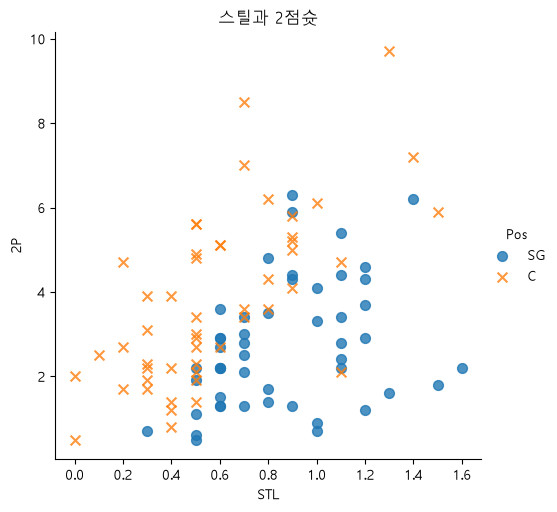

In [14]:
sns.lmplot(
    x = 'STL',
    y = '2P',
    data = df,
    fit_reg = False,            
    scatter_kws={'s' : 50},     # 좌표상의 점의 크기
    hue = 'Pos',
    markers=['o', 'x']
)

plt.title('스틸과 2점슛')
plt.show()

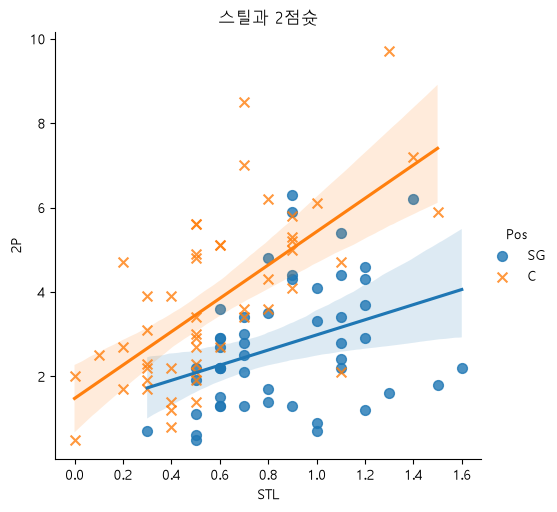

In [15]:
sns.lmplot(
    x = 'STL',
    y = '2P',
    data = df,
    fit_reg = True,             # 회귀선
    scatter_kws={'s' : 50},     # 좌표상의 점의 크기
    hue = 'Pos',
    markers=['o', 'x']
)

plt.title('스틸과 2점슛')
plt.show()

> 스틸과 2점슛의 속성으로 테이터를 분포시킬 경우 슈팅가드와 센터의 경계가 너무 근접해 분류하기에 모호함

#### 어시스트와 2점슛 데이터 시각화

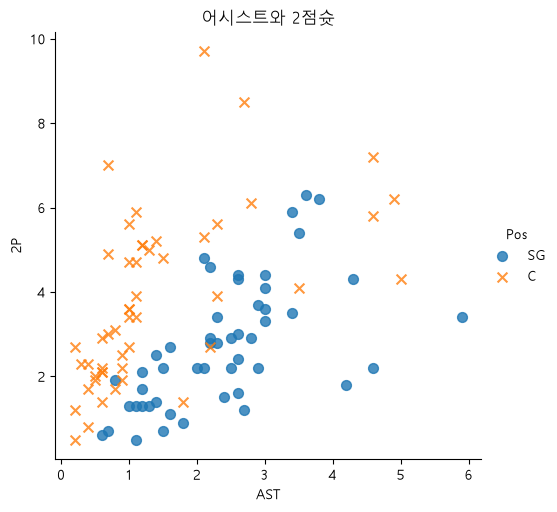

In [16]:
sns.lmplot(
    x = 'AST',
    y = '2P',
    data = df,
    fit_reg = False,
    scatter_kws={'s' : 50}, # 좌표상의 점의 크기
    hue = 'Pos',
    markers=['o', 'x']
)

plt.title('어시스트와 2점슛')
plt.show()

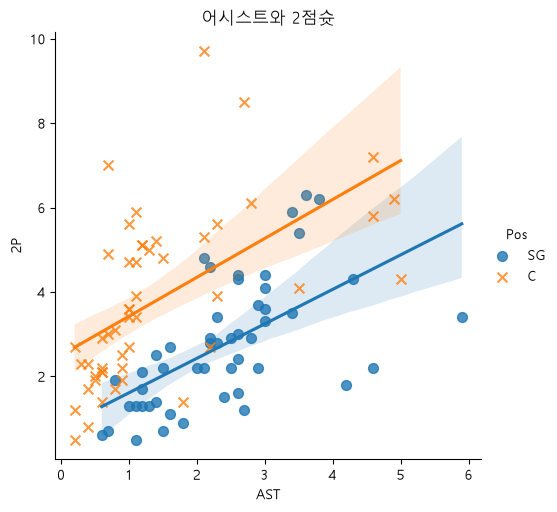

In [17]:
sns.lmplot(
    x = 'AST',
    y = '2P',
    data = df,
    fit_reg = True,
    scatter_kws={'s' : 50}, # 좌표상의 점의 크기
    hue = 'Pos',
    markers=['o', 'x']
)

plt.title('어시스트와 2점슛')
plt.show()

>  어시스트와 2점슛의 속성으로 테이터를 분포시킬 경우 슈팅가드와 센터의 경계가 너무 근접해 분류하기에 모호함  
> 단, 스틸과 2점슛의 속성보다는 나은 편

### 블로킹과 3점슛의 데이터 시각화

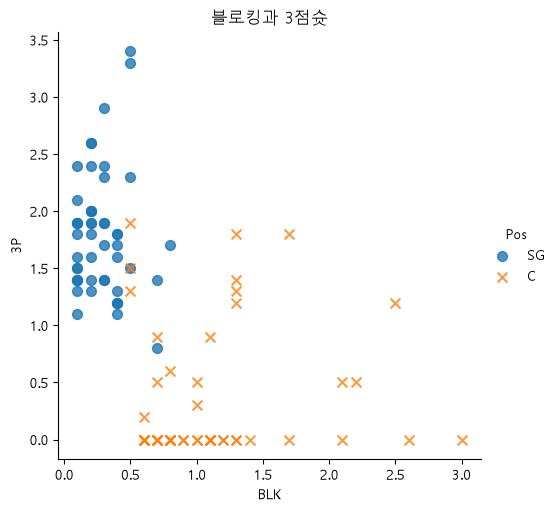

In [20]:
sns.lmplot(
    x = 'BLK',
    y = '3P',
    data = df,
    fit_reg = False,
    scatter_kws={'s' : 50}, # 좌표상의 점의 크기
    hue = 'Pos',
    markers=['o', 'x']
)

plt.title('블로킹과 3점슛')
plt.show()

### 리바운드와 3점슛

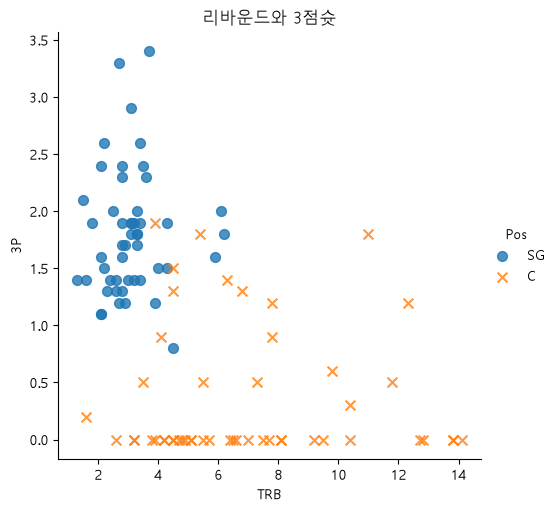

In [21]:
sns.lmplot(
    x = 'TRB',
    y = '3P',
    data = df,
    fit_reg = False,
    scatter_kws={'s' : 50}, 
    hue = 'Pos',
    markers=['o', 'x']
)

plt.title('리바운드와 3점슛')
plt.show()

> EDA(Explorary Data Analysis : 탐색적 데이터 분석) 결과  
>분별력 없는 Feature를 데이터에서 제거하기 위해 시각화를 해본 결과 2P, AST, STL은 분별력이 없는 것으로 판단

In [22]:
# 분별력 없는 Feature를 데이터에서 제거
df.drop(
    ['2P', 'AST', 'STL'],
    axis='columns',
    inplace=True
)

df.head()

,Player,Pos,3P,TRB,BLK
0,Alex Abrines,SG,1.4,1.3,0.1
1,Steven Adams,C,0.0,7.7,1.0
2,Alexis Ajinca,C,0.0,4.5,0.6
3,Chris Andersen,C,0.0,2.6,0.6
4,Will Barton,SG,1.5,4.3,0.5


#### 학습 데이터와 테스트 데이터로 나누기

In [23]:
from sklearn.model_selection import train_test_split

In [25]:
# 다듬어진 데이터에서 20%를 테스트 데이터로 분류
train, test  = train_test_split(
    df,
    random_state=42,
    stratify=df.Pos,
    test_size=0.2
)

In [26]:
# 데이터 갯수 확인
print(train.shape)
print(test.shape)

(80, 5)
(20, 5)


In [27]:
train.head()

,Player,Pos,3P,TRB,BLK
31,Pau Gasol,C,0.9,7.8,1.1
5,Nicolas Batum,SG,1.8,6.2,0.4
19,Allen Crabbe,SG,1.7,2.9,0.3
32,Manu Ginobili,SG,1.3,2.3,0.2
36,Danny Green,SG,1.7,3.3,0.8


In [28]:
test.head()

,Player,Pos,3P,TRB,BLK
13,Avery Bradley,SG,2.0,6.1,0.2
58,Zach LaVine,SG,2.6,3.4,0.2
22,Troy Daniels,SG,2.1,1.5,0.1
4,Will Barton,SG,1.5,4.3,0.5
16,Willie Cauley-Stein,C,0.0,4.5,0.6


In [29]:
# 데이터 저장
train.to_csv("../Data/basketball_train.csv", index=None)
test.to_csv("../Data/basketball_test.csv", index=None)